## Exploration

In [1]:
dataset_root = "../egocart/"

# Train paths
train_path = dataset_root + "train_set/"
train_depth_path = train_path + "train_depth/"
train_rgb_path = train_path + "train_RGB/"

# Test paths
test_path = dataset_root + "test_set/"
test_depth_path = test_path + "test_depth/"
test_rgb_path = test_path + "test_RGB/"

In [2]:
import pandas as pd 

# Loading the training data in a DataFrame
column_names = ["rgb_image_filename", "depth_image_filename", "x", "y", "u", "v", "c"]
train_df = pd.read_csv(train_path + "train_set.txt", sep="\s+", names=column_names)

# Loading the testing data in a DataFrame
test_df = pd.read_csv(test_path + "test_set.txt", sep="\s+", names=column_names)

In [3]:
train_df.shape, test_df.shape

((13360, 7), (6171, 7))

In [3]:
# Displaying the first 5 rows of the training DataFrame
train_df.head(5)

,rgb_image_filename,depth_image_filename,x,y,u,v,c
0,018020.jpg,dL_018020.jpg,-17.899198,4.772327,0.999056,-0.043372,16
1,018040.jpg,dL_018040.jpg,-17.931599,4.761239,0.996806,-0.079747,16
2,018060.jpg,dL_018060.jpg,-17.958966,4.736847,0.991619,-0.129038,16
3,018080.jpg,dL_018080.jpg,-17.992269,4.726340,0.985513,-0.169410,16
4,018100.jpg,dL_018100.jpg,-18.029794,4.716078,0.978314,-0.206909,16


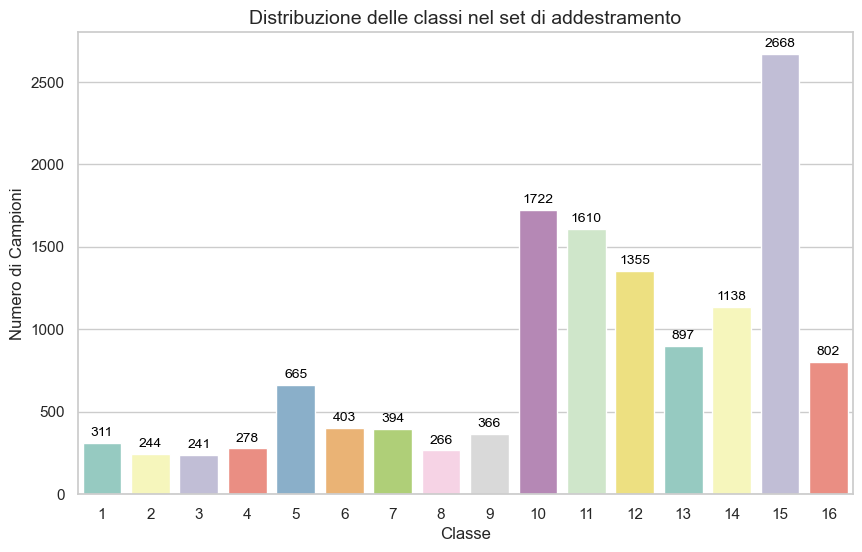

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Visualizing the class distribution in the training set
fig = plt.figure(figsize=(10,6))
ax = sns.countplot(x="c", data=train_df, hue="c", legend=False, palette="Set3")

#plt.title("Class Distribution in the Training Set")
#plt.xlabel("Class", fontsize=12)
#plt.ylabel("Number of Samples", fontsize=12)
plt.title("Distribuzione delle classi nel set di addestramento", fontsize=14)
plt.xlabel("Classe", fontsize=12)
plt.ylabel("Numero di Campioni", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()
fig.savefig('distribuzione_classi.png', dpi=300)



In [5]:
from PIL import Image

sample_img = Image.open(train_rgb_path + train_df.iloc[0]["rgb_image_filename"])

# Displaying the format, size, and mode of a random sample image
print(sample_img.format, sample_img.size, sample_img.mode)

JPEG (1280, 720) RGB


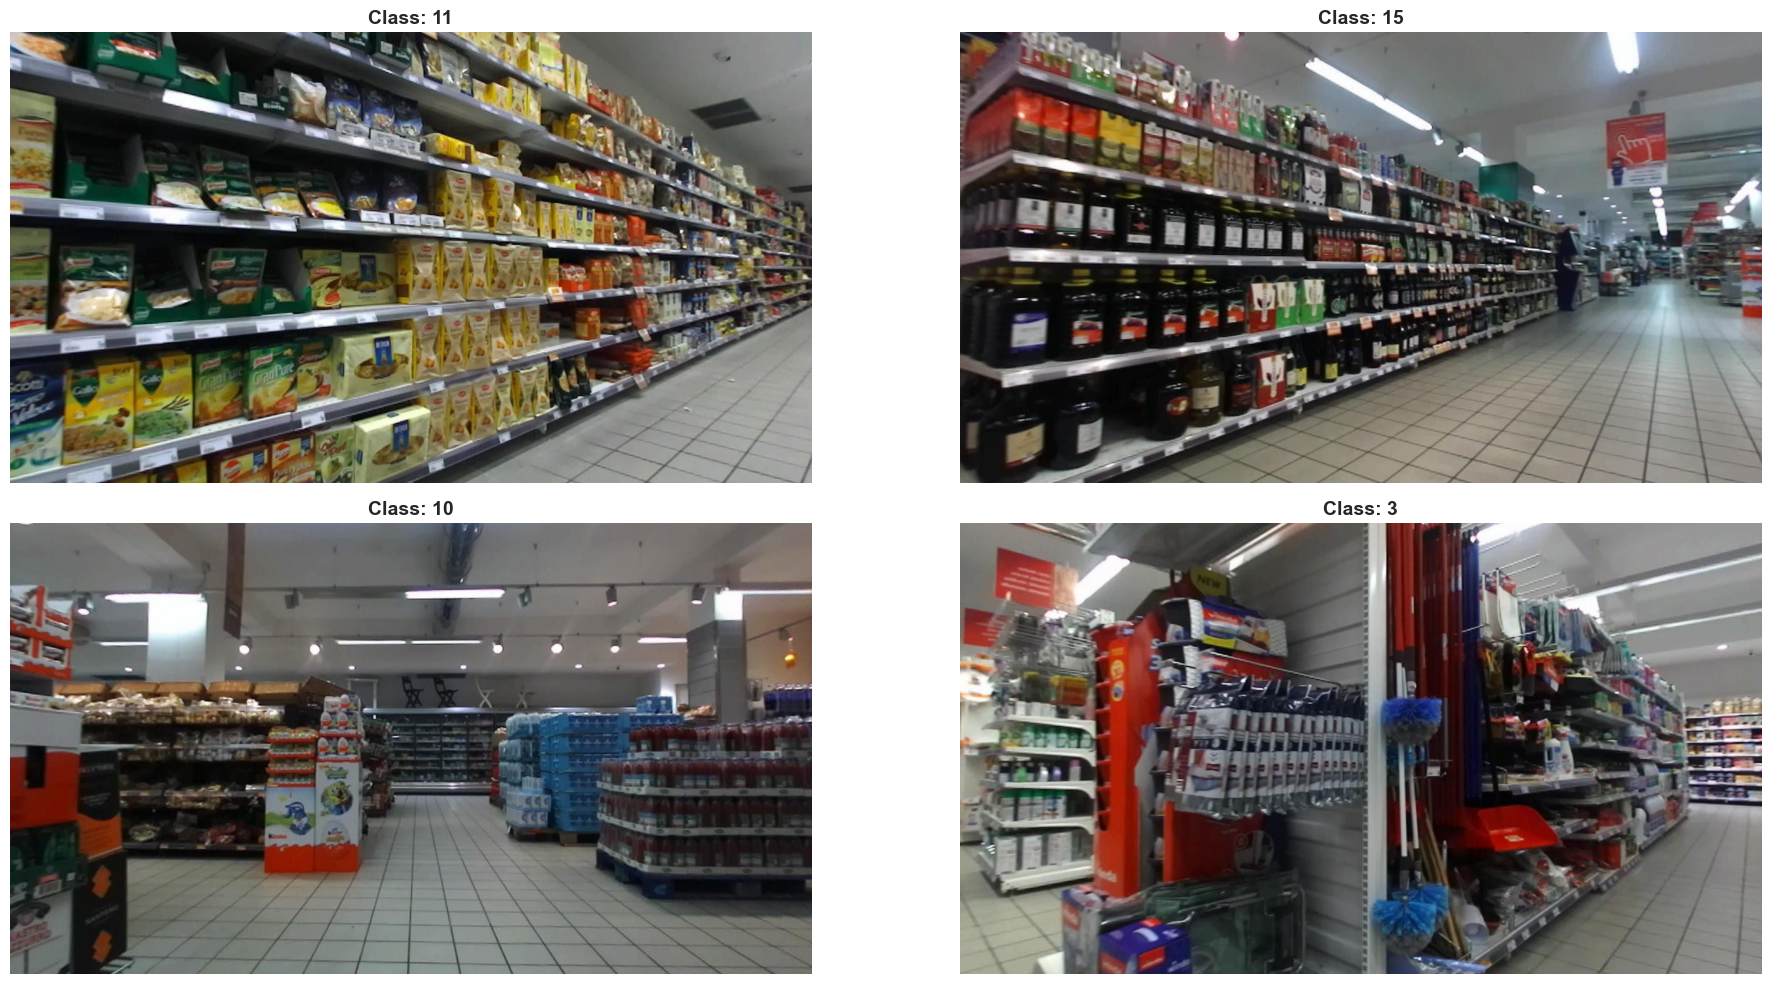

In [6]:
# Displaying sample images from the training set for some classes
target_classes = [15, 3, 10, 11]

selected_samples = train_df[train_df['c'].isin(target_classes)].groupby('c').head(1)

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

for ax, (_, row) in zip(axes.flat, selected_samples.iterrows()):
    img_path = train_rgb_path + row['rgb_image_filename']
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"Class: {row['c']}", fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()